In [2]:
# Import all python Libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# We have LOAD dataset
df = pd.read_csv("house_price_cleaning.csv")
df.head()

,Property_ID,City,Locality,Property_Type,Bedrooms,Area_sqft,Year_Built,Condition,Parking_Spaces,Sale_Price_INR
0,HP1201,Pune,Noida,Apartment,2,3166.0,1988.0,New,3,34070000.0
1,HP1143,Hyderabad,Baner,Apartment,4,4163.0,1989.0,Needs Renovation,1,25600000.0
2,HP1265,Hyderabad,Whitefield,Villa,3,2117.0,2000.0,Needs Renovation,1,20150000.0
3,HP1490,Pune,Gachibowli,Apartment,4,3134.0,1993.0,Average,2,30340000.0
4,HP1213,Delhi,Whitefield,Independent House,5,2924.0,2018.0,Good,1,33650000.0


In [4]:
df.tail()

,Property_ID,City,Locality,Property_Type,Bedrooms,Area_sqft,Year_Built,Condition,Parking_Spaces,Sale_Price_INR
503,HP1049,Pune,Kharadi,Apartment,4,4041.0,1984.0,New,1,37300000.0
504,HP1261,Pune,Andheri,Independent House,4,4131.0,2008.0,Good,2,51730000.0
505,HP1313,Pune,Kharadi,Row House,3,NaN,2015.0,Good,2,33490000.0
506,HP1208,Hyderabad,Gachibowli,Villa,1,4323.0,1983.0,Good,2,38410000.0
507,HP1458,Mumbai,Kharadi,Apartment,3,3629.0,1993.0,New,2,26720000.0


In [10]:
df.info()  # I have to Check information about my dataset like column name,data types etc.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   property_id     508 non-null    object 
 1   city            508 non-null    object 
 2   locality        488 non-null    object 
 3   property_type   508 non-null    object 
 4   bedrooms        508 non-null    int64  
 5   area_sqft       496 non-null    float64
 6   year_built      498 non-null    float64
 7   condition       490 non-null    object 
 8   parking_spaces  508 non-null    int64  
 9   sale_price_inr  498 non-null    float64
dtypes: float64(3), int64(2), object(5)
memory usage: 39.8+ KB


In [11]:
df.describe()  # I have to Check Statistical summary of dataset here

,bedrooms,area_sqft,year_built,parking_spaces,sale_price_inr
count,508.000000,496.000000,498.000000,508.000000,4.980000e+02
mean,2.925197,2605.229839,2001.540161,1.322835,2.282504e+07
std,1.190990,1602.679311,13.842437,0.843884,1.252363e+07
min,0.000000,50.000000,1890.000000,0.000000,5.000000e+04
25%,2.000000,1529.500000,1991.000000,1.000000,1.275500e+07
50%,3.000000,2598.000000,2001.000000,1.000000,2.050000e+07
75%,4.000000,3582.250000,2013.000000,2.000000,3.120750e+07
max,12.000000,25000.000000,2035.000000,3.000000,9.500000e+07


In [12]:
df.isnull().sum()  # I have To check missing values present  in my dataset

property_id        0
city               0
locality          20
property_type      0
bedrooms           0
area_sqft         12
year_built        10
condition         18
parking_spaces     0
sale_price_inr    10
dtype: int64

In [13]:
# Find Missing count and their percentage according to perticular column which have missing values.
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

pd.DataFrame({
    "Missing_Count": missing_count,
    "Missing_Percentage": missing_percent
}).sort_values(by="Missing_Percentage", ascending=False)

,Missing_Count,Missing_Percentage
locality,20,3.937008
condition,18,3.543307
area_sqft,12,2.362205
year_built,10,1.968504
sale_price_inr,10,1.968504
property_id,0,0.000000
city,0,0.000000
property_type,0,0.000000
bedrooms,0,0.000000
parking_spaces,0,0.000000


In [14]:
# To fill missing values to numerical or categorical columns according to mean.mode and median

import warnings
warnings.filterwarnings("ignore")

df["locality"].fillna(df["locality"].mode()[0], inplace=True)

df["condition"].fillna(df["condition"].mode()[0], inplace=True)

df["area_sqft"].fillna(df["area_sqft"].median(), inplace=True)

df["year_built"].fillna(df["year_built"].median(), inplace=True)

df["sale_price_inr"].fillna(df["sale_price_inr"].median(), inplace=True)

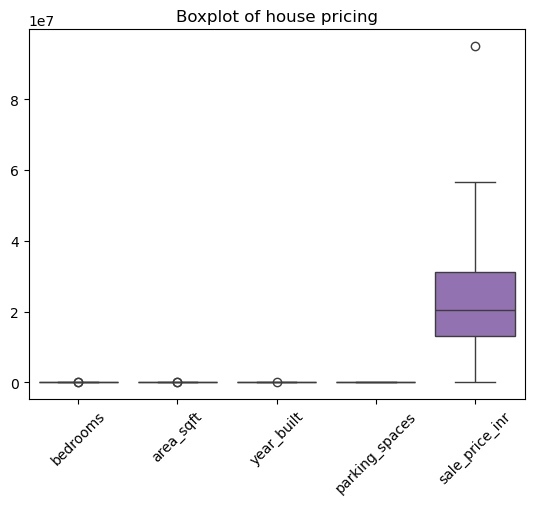

In [15]:
# I used the Box plot to identify outliers in the house price data.

sns.boxplot(data =df)
plt.title("Boxplot of house pricing")
plt.xticks(rotation =45)
plt.show()

In [ ]:
# This outliers are important because extreamly high or low values can affect statistical analysis.

In [16]:


Q1 = df["bedrooms"].quantile(0.25)
Q3 = df["bedrooms"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df["bedrooms"] = np.where(df["bedrooms"] > upper_bound, upper_bound, df["bedrooms"])
df["bedrooms"] = np.where(df["bedrooms"] < lower_bound, lower_bound, df["bedrooms"])

In [17]:
Q1 = df["area_sqft"].quantile(0.25)
Q3 = df["area_sqft"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df["area_sqft"] = np.where(df["area_sqft"] > upper_bound, upper_bound, df["area_sqft"])
df["area_sqft"] = np.where(df["area_sqft"] < lower_bound, lower_bound, df["area_sqft"])

In [18]:
Q1 = df["year_built"].quantile(0.25)
Q3 = df["year_built"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df["year_built"] = np.where(df["year_built"] > upper_bound, upper_bound, df["year_built"])
df["year_built"] = np.where(df["year_built"] < lower_bound, lower_bound, df["year_built"])

In [19]:

Q1 = df["sale_price_inr"].quantile(0.25)
Q3 = df["sale_price_inr"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df["sale_price_inr"] = np.where(df["sale_price_inr"] > upper_bound, upper_bound, df["sale_price_inr"])
df["sale_price_inr"] = np.where(df["sale_price_inr"] < lower_bound, lower_bound, df["sale_price_inr"])

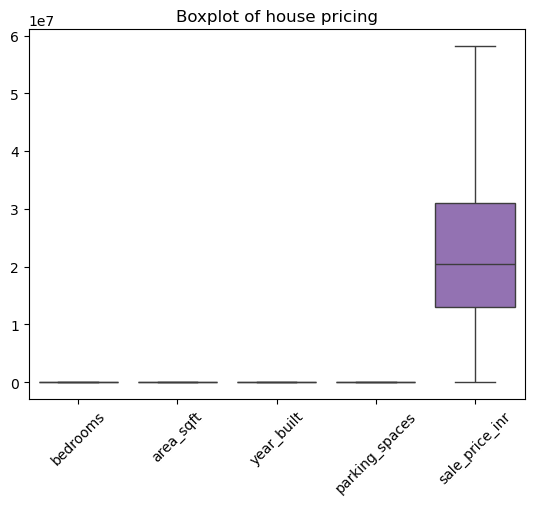

In [20]:
sns.boxplot(data =df)
plt.title("Boxplot of house pricing")
plt.xticks(rotation =45)
plt.show()

In [21]:
df.isnull().sum() # Here I cleaned the data 

property_id       0
city              0
locality          0
property_type     0
bedrooms          0
area_sqft         0
year_built        0
condition         0
parking_spaces    0
sale_price_inr    0
dtype: int64

In [22]:
df.head()

,property_id,city,locality,property_type,bedrooms,area_sqft,year_built,condition,parking_spaces,sale_price_inr
0,HP1201,Pune,Noida,Apartment,2.0,3166.0,1988.0,New,3,34070000.0
1,HP1143,Hyderabad,Baner,Apartment,4.0,4163.0,1989.0,Needs Renovation,1,25600000.0
2,HP1265,Hyderabad,Whitefield,Villa,3.0,2117.0,2000.0,Needs Renovation,1,20150000.0
3,HP1490,Pune,Gachibowli,Apartment,4.0,3134.0,1993.0,Average,2,30340000.0
4,HP1213,Delhi,Whitefield,Independent House,5.0,2924.0,2018.0,Good,1,33650000.0


In [23]:
df.duplicated().sum()

np.int64(8)

In [24]:
df.drop_duplicates(inplace =True)

In [25]:
df.rename(columns=lambda x: x.lower(), inplace=True)
df.head()

,property_id,city,locality,property_type,bedrooms,area_sqft,year_built,condition,parking_spaces,sale_price_inr
0,HP1201,Pune,Noida,Apartment,2.0,3166.0,1988.0,New,3,34070000.0
1,HP1143,Hyderabad,Baner,Apartment,4.0,4163.0,1989.0,Needs Renovation,1,25600000.0
2,HP1265,Hyderabad,Whitefield,Villa,3.0,2117.0,2000.0,Needs Renovation,1,20150000.0
3,HP1490,Pune,Gachibowli,Apartment,4.0,3134.0,1993.0,Average,2,30340000.0
4,HP1213,Delhi,Whitefield,Independent House,5.0,2924.0,2018.0,Good,1,33650000.0


In [30]:
df["area_sqft"] =df["area_sqft"].astype("int64")

In [31]:
df["bedrooms"] =df["bedrooms"].astype("int64")
df["year_built"] =df["year_built"].astype("int64")

In [32]:
df.head()

,property_id,city,locality,property_type,bedrooms,area_sqft,year_built,condition,parking_spaces,sale_price_inr
0,HP1201,Pune,Noida,Apartment,2,3166,1988,New,3,34070000.0
1,HP1143,Hyderabad,Baner,Apartment,4,4163,1989,Needs Renovation,1,25600000.0
2,HP1265,Hyderabad,Whitefield,Villa,3,2117,2000,Needs Renovation,1,20150000.0
3,HP1490,Pune,Gachibowli,Apartment,4,3134,1993,Average,2,30340000.0
4,HP1213,Delhi,Whitefield,Independent House,5,2924,2018,Good,1,33650000.0


In [33]:
df.drop(columns =["property_id"], inplace =True)

In [34]:
df.head()

,city,locality,property_type,bedrooms,area_sqft,year_built,condition,parking_spaces,sale_price_inr
0,Pune,Noida,Apartment,2,3166,1988,New,3,34070000.0
1,Hyderabad,Baner,Apartment,4,4163,1989,Needs Renovation,1,25600000.0
2,Hyderabad,Whitefield,Villa,3,2117,2000,Needs Renovation,1,20150000.0
3,Pune,Gachibowli,Apartment,4,3134,1993,Average,2,30340000.0
4,Delhi,Whitefield,Independent House,5,2924,2018,Good,1,33650000.0


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, 0 to 507
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   city            500 non-null    object 
 1   locality        500 non-null    object 
 2   property_type   500 non-null    object 
 3   bedrooms        500 non-null    int64  
 4   area_sqft       500 non-null    int64  
 5   year_built      500 non-null    int64  
 6   condition       500 non-null    object 
 7   parking_spaces  500 non-null    int64  
 8   sale_price_inr  500 non-null    float64
dtypes: float64(1), int64(4), object(4)
memory usage: 39.1+ KB


In [36]:
df.isnull().sum()

city              0
locality          0
property_type     0
bedrooms          0
area_sqft         0
year_built        0
condition         0
parking_spaces    0
sale_price_inr    0
dtype: int64

In [37]:
df.shape

(500, 9)

In [38]:
df.to_csv("house_pricing_cleanedData.csv")

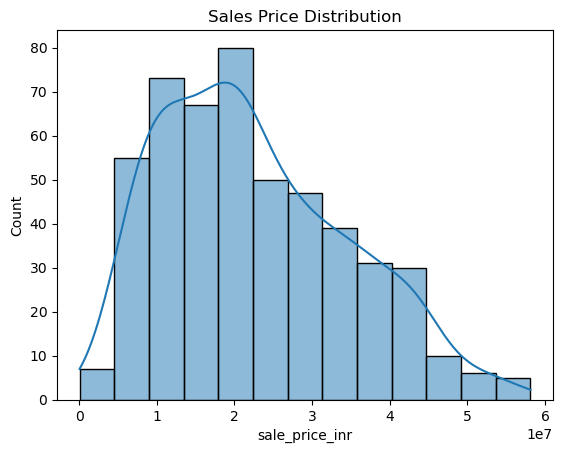

In [39]:
# UNIVARIED ANALYSIS- I performed this analysis to check sales price distribution.

sns.histplot( data = df ,x ="sale_price_inr",kde = True)
plt.title("Sales Price Distribution")
plt.show()


In [40]:
# INSIGHTS: We have to noticed that most of sales price are high,we have to say that their is high crowded area.
# Sales prices are not uniformally distributed.


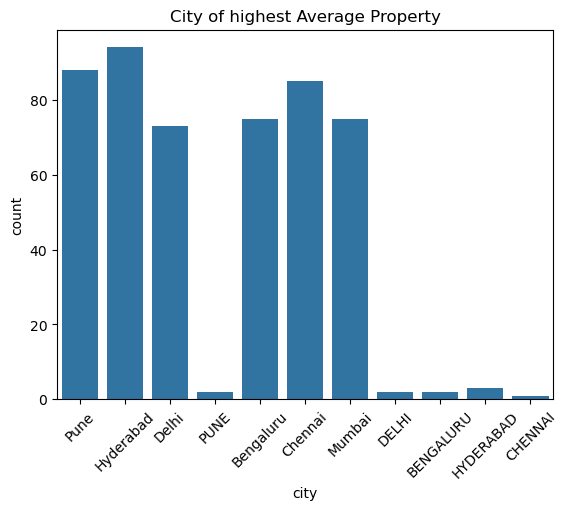

In [41]:
# Which city has the highest average property
# 
sns.countplot(data =df ,x ="city")
plt.title("City of highest Average Property")
plt.xticks(rotation =45)
plt.show()

In [ ]:
# This graph shows distribution of properties across different cities.(Property count)

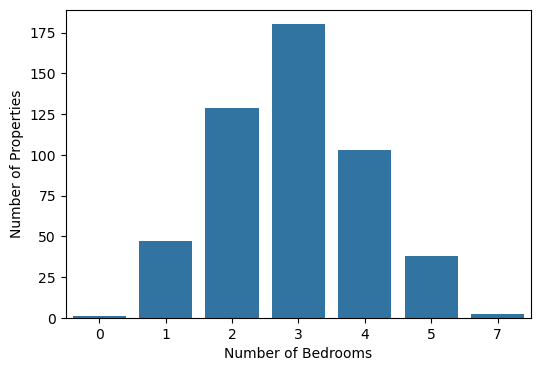

In [42]:
# What is the distribution of the number of Bedrooms.

plt.figure(figsize=(6,4))
sns.countplot(data =df ,x="bedrooms")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Number of Properties")
plt.show()

In [43]:
# This graph shows which bedroom configuration is most common in the dataset.

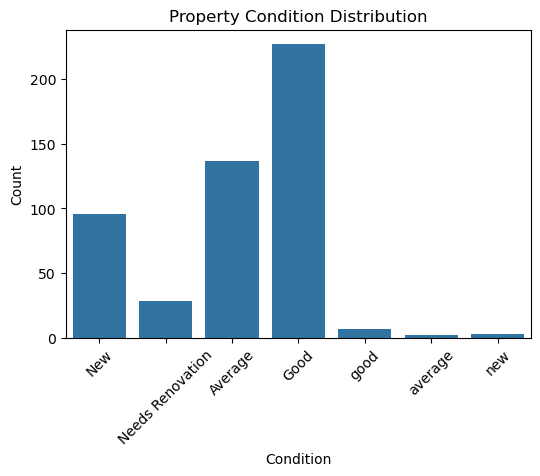

In [44]:
# How are the property distributed according to their condition.

plt.figure(figsize=(6,4))
sns.countplot(data =df,x ="condition")
plt.title("Property Condition Distribution")
plt.xlabel("Condition")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [45]:
# This graph shows number of properties in different conditions such as new,Good,Average and need renovation.

In [46]:
# BIVARIATE ANALYSIS

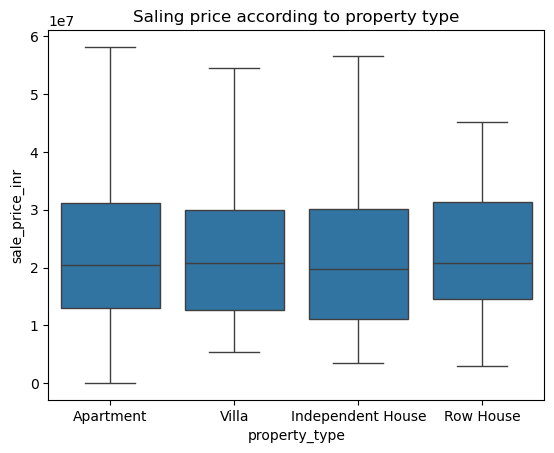

In [47]:
# find average price with respect to propery type

sns.boxplot(data =df ,y= "sale_price_inr", x ="property_type")
plt.title("Saling price according to property type")

plt.show()

In [48]:
# INSIGHTS: IT helps to compare sales prices with different property types,we can say according to people 
# choose which is highest property type their prices higher .

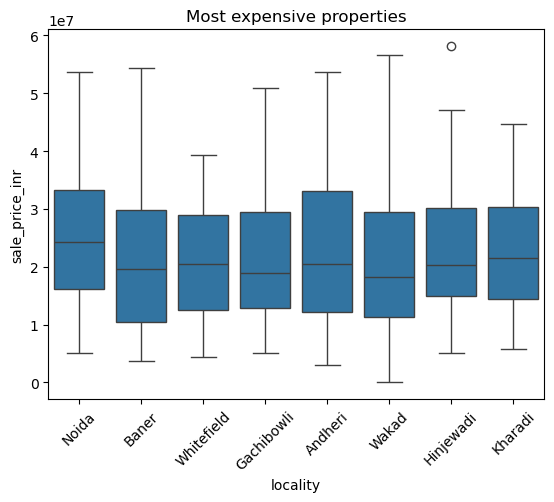

In [49]:
# which locality has the most expensive properties
# This graph shows the relationship between area and house price.

sns.boxplot(data =df, x ="locality" ,y ="sale_price_inr")
plt.title("Most expensive properties")
plt.xticks(rotation =45)
plt.show()

In [50]:
# INSIGHTS: As per this grap the living area or locality increases ,the house price also tends to increases.
# Highest living areas generally have higher prices.

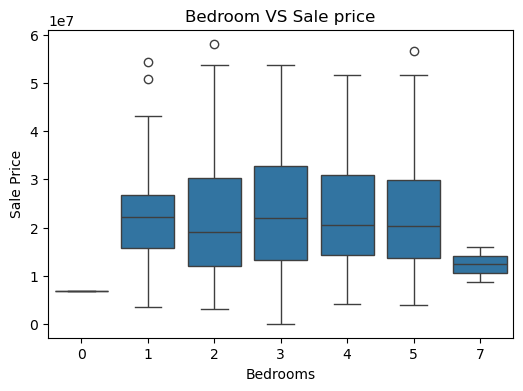

In [51]:
plt.figure(figsize=(6,4))
sns.boxplot(data =df,x="bedrooms",y="sale_price_inr")
plt.title("Bedroom VS Sale price")
plt.xlabel("Bedrooms")
plt.ylabel("Sale Price")
plt.show()

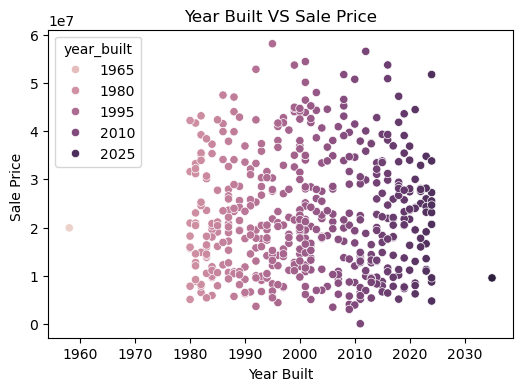

In [54]:
# Is there a relationship between year built and sale price.

plt.figure(figsize=(6,4))
sns.scatterplot(data = df,x="year_built",y="sale_price_inr",hue="year_built")
plt.title("Year Built VS Sale Price")
plt.xlabel("Year Built")
plt.ylabel("Sale Price ")
plt.show()


In [ ]:
# Multivariate Analysis

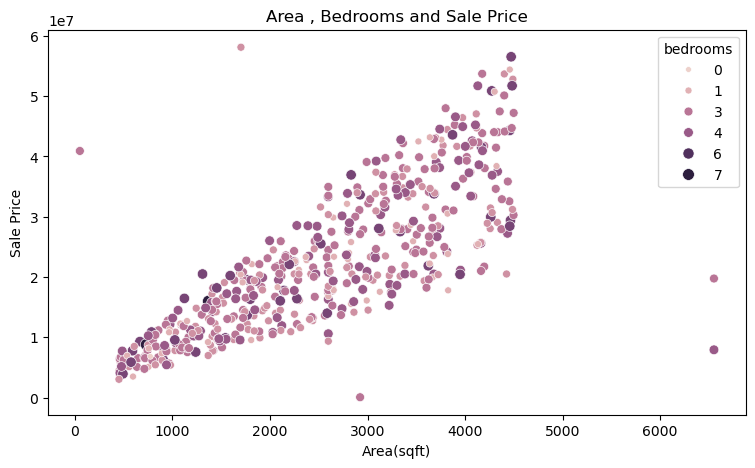

In [58]:
# How do area, bedrooms and sale price relate to each other.

plt.figure(figsize=(9,5))
sns.scatterplot(data =df,x="area_sqft",y="sale_price_inr",hue="bedrooms",size="bedrooms")
plt.title("Area , Bedrooms and Sale Price")
plt.xlabel("Area(sqft)")
plt.ylabel("Sale Price")
plt.show()

In [ ]:
# This visualization shows the relationship between Area and Sale Price, while color and size represent the number of bedrooms.

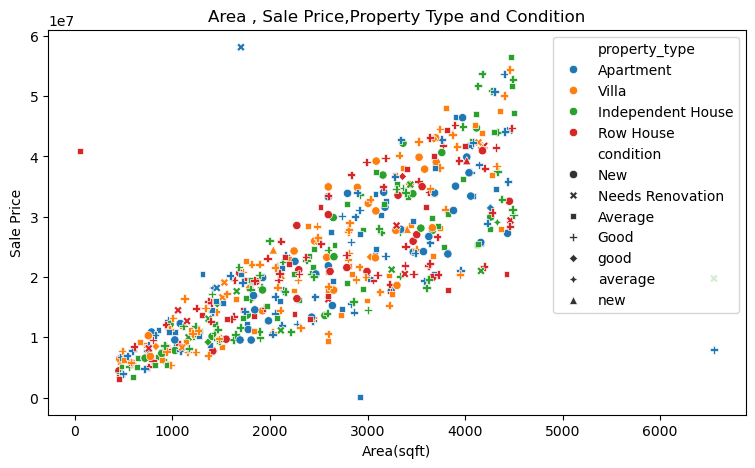

In [57]:
# How to property Type,area and sale price vary together.

plt.figure(figsize=(9,5))
sns.scatterplot(data =df,x="area_sqft",y="sale_price_inr",hue="property_type",style="condition")
plt.title("Area , Sale Price,Property Type and Condition")
plt.xlabel("Area(sqft)")
plt.ylabel("Sale Price")
plt.show()

In [ ]:
# This visualization compares the relationship between Area and Sale Price for different Property Types while the marker style represent property condition.